In [34]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import plotly.express as px

## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors

- Silas Jude: Conceptualization, Software, Visualizaton, Writing - review & editing
- Medha Nemani: Conceptualization, Background research, Project administration, Writing - original draft
- Vivian Lin: Background research, Software, Writing - original draft
- Justin Zeng: Data curation, Analysis, Experimental investigation
- Devon Cheng: Writing - original draft, Software, Methodology

# Research Question

To what degree are daily average hours of study time, extracurricular time, sleep time, social time, and physical activity predictive of an undergraduate student's GPA and self-reported stress levels?



## Background and Prior Work

Students do more than sit in classrooms listening to instructors lecture on important topics. They are proactive in their learning, socialize with diverse groups of peers, and engage in enriching activities. With the many responsibilities that come with being a student, the primary goal for most is to perform well academically, while being able to manage other aspects of their life successfully. As students, we are interested in how various personal and academic lifestyle factors can have an effect on academic standing.

Existing literature on this topic explores similar research into how personal lifestyle factors are correlated with stress level and academic standing for students. One research study exploring lifestyle factors and academic achievement found that mainly spiritual growth and living situation showed a significant positive relationship with academic achievement. <a name="cite_ref-1"></a>[<sup>1</sup>](#cite_note-1)

Another research study by Blasche et al. was conducted on medical students at the Medical Center of Vienna, Austria where they access the effects of academic work on students’ wellbeing, specifically fatigue, vigor, and distress. They concluded that the longer students work on a mentally demanding task, the more greater degree of fatigue and distress they face, showing positive correlations between number of hours of working on the task and fatigue/distress. <a name="cite_ref-2"></a>[<sup>2</sup>](#cite_note-2)

Al-Roomy dives deeper specifically how stress affects academic performances, concluding that students with higher stress levels tend to achieve lower academic scores and that medical students experience higher levels of stress than nonmedical students. <a name="cite_ref-3"></a>[<sup>3</sup>](#cite_note-3)

While existing literature covers the relationship between student’s well being and academic achievement, our work aims at addressing the gap in literature by identifying the factor that most significantly contributes to stress level and GPA. These factors encompass various aspects of students’ lifestyle and responsibilities that shape their academic performances. As such, our topic specifically explores how number of hours sleeping, studying, participating in extracurricular activities, socializing, and doing physical activity effect stress level and GPA, if at all. We can additionally adjust for each variable in our calculations for the others, thereby addressing confounding factors.

1. <a name="cite_note-1"></a> [^](#cite_ref-1) Bakouei F, Omidvar S, Seyediandi SJ, Bakouei S. Are healthy lifestyle behaviors positively associated with the academic achievement of the university students? J Adv Med Educ Prof. 2019 Oct;7(4):224-229. doi: 10.30476/jamp.2019.74888. PMID: 31750361; PMCID: PMC6820013.
2. <a name="cite_note-2"></a> [^](#cite_ref-2) Blasche G, Khanaqa TAK, Wagner-Menghin M. Mentally Demanding Work and Strain: Effects of Study Duration on Fatigue, Vigor, and Distress in Undergraduate Medical Students. Healthcare (Basel). 2023 Jun 7;11(12):1674. doi: 10.3390/healthcare11121674. PMID: 37372792; PMCID: PMC10298359.
3. <a name="cite_note-3"></a> [^](#cite_ref-3) Al-Roomy M. Assessing the correlation between perceived stress and academic achievement among health sciences students. Front Med (Lausanne). 2026 Jan 9;12:1734838. doi: 10.3389/fmed.2025.1734838. PMID: 41585274; PMCID: PMC12827518.

# Hypothesis


We predict study time will be the most significant predictor of both GPA and stress levels, which tracks with the data from Al-Roomy, while sleep time will likely be positively correlated with GPA and negatively correlated with stress levels. We expect higher exercise levels, social time, and extracurricular time to be predictive of lower stress levels, which may lead to higher GPAs according to the data from Blasche et al.

## Data

### Ideal dataset description
Ideally we would have data demonstrating academic habits such as time spent studying, health habits such as time spent sleeping, exercise, caffeine intake, and type of diet, and other habits such as time spent in extracurriculars, socializing, and along with stress levels and GPAs for individual students. Most of the variables would ideally be measured with time in minutes (to be as accurate as possible) except for GPA and stress which could be measured through a variety of factors such as average heart rate, cortisol levels, sweat activity, and temperature. A formal medical assessment for stress level would be more ideal given that it would likely lead to more accurate results, meaning that the collection of data for this ideal dataset would have to be authorized by a medical professional or data would have to be obtained from an authorized clinical trial. However, although not as ideal, to obtain a larger amount of datapoints, factors like stress levels would likely be self-reported. We would need a somewhat large dataset because we are observing a large number of variables, particularly if there is missing data, to get a complete picture. Data could come from national-level, district-level, etc. surveys, as at least some of it (stress levels) would likely be self-reported. It could be stored in a csv or any other file, as the data are pretty simple. We found a dataset with many of these variables on [Kaggle](https://www.kaggle.com/datasets/steve1215rogg/student-lifestyle-dataset), where it's publicly available to download. This comes from a Google form survey, with self-reported data from 2000 primarily Indian students. This dataset includes the variables of hours spent studying, sleeping, doing extracurriculars, exercising, socializing, as well as GPA and stress levels (self-reported on a scale of low-moderate-high). Different from our ideal dataset, this real dataset lacks some variables we had thought about (including factors like diet, caffeine) and also measures stress through a self-reported metric as opposed to a more medical metric as discussed previously. All the variables can be directly used for our question.

In [35]:
# Setup code -- this only needs to be run once after cloning the repo!
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://drive.google.com/uc?id=10ScFVNQaxMvGg8HrvUeBz4NSoQLMCLN8', 'filename':'student_lifestyle_dataset.csv'},
]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress: 100%|██████████| 1/1 [00:01<00:00,  1.45s/it]

Successfully downloaded: student_lifestyle_dataset.csv


### Student Lifestyle Dataset

This dataset is a survey styled dataset with 2,000 observations (rows) and 7 variables (columns). Each row represents one student’s response, and the dataset records how students spend time across several common activities along with two outcomes -> GPA and stress level. Because it is survey based, the values are personal estimates rather than exact measurements.

The most important metrics used in this dataset are time/use variables measured in hours/day. These include Study_Hours_Per_Day, which represents time spent doing academic work such as reading, assignments, studying; Sleep_Hours_Per_Day, representing rest and recovery; Social_Hours_Per_Day, reflecting time spent socializing; Extracurricular_Hours_Per_Day, which reflects time spent in organizations, hobbies, or other structured activities outside class; and Physical_Activity_Hours_Per_Day, which represents time spent exercising or doing fitness activities. These metrics are directly aligned with our research question since they capture how students allocate time between academics, rest, social, and other commitments.
The primary outcomes we are interested in predicting are GPA and Stress Level. GPA is a numeric measure of academic performance. Stress Level is a categorical variable that measures well being.

Because the dataset is composed of responses from a Google Form survey, there is a potential self-selection bias in which respondents are limited to individuals who are willing to participate and share information about their lifestyle and habits. Individuals who are more comfortable with self-disclosure about their lifestyle tend to be health-conscious, organized, and self-reflective, leading to overrepresentation of individuals with more “ideal” lifestyles or at least self-reported behaviors that appear more desirable. Furthermore, stress levels are not standardized, and because this variable is self-reported, respondents may interpret and report them differently based on their current beliefs, experience, or perception.

Another concern of this dataset is that the respondents are primarily from India, meaning that it reflects India’s local norms and cultural context and is not representative of students on a global scale. India is one of the many countries where the family places high expectations on students to perform well academically. As a result, respondents are more likely to report higher stress levels, and their interpretation of what constitutes “high stress levels” may differ, potentially affecting how stress is interpreted in the dataset.

Google Form surveys must be completed online through a device (computer, cell phone, etc.) and with decent internet connectivity. Those who reside in urban and more developed areas have higher accessibility to reliable connections and devices, while those who reside in rural and more remote areas lack this infrastructure, though this gap is shrinking, making this bias likely minimal but not negligible.

In [36]:
df = pd.read_csv('data/00-raw/student_lifestyle_dataset.csv')
df.rename(columns={'Student_ID': 'student id',
                   'Study_Hours_Per_Day': 'study hours',
                   'Extracurricular_Hours_Per_Day': 'extracurricular hours',
                   'Sleep_Hours_Per_Day': 'sleep hours',
                   'Social_Hours_Per_Day': 'social hours',
                   'Physical_Activity_Hours_Per_Day': 'physical activity hours',
                   'Stress_Level': 'stress level',
                   'GPA': 'gpa'
                   }, inplace=True)
df.head()

,student id,study hours,extracurricular hours,sleep hours,social hours,physical activity hours,gpa,stress level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


In [37]:
print(f"Total number of missing values in the dataset: {df.isna().sum().sum()}")
print(f"Variables: {df.columns.tolist()[1:]}; length: {len(df.columns.tolist()[1:])}")
print(f"Potential values for stress levels: {df['stress level'].unique()}")
print(f"GPA range: [{df['gpa'].min()}, {df['gpa'].max()}]")
print(f"Number of observations: {df.shape[0]}")
df.describe()

Total number of missing values in the dataset: 0
Variables: ['study hours', 'extracurricular hours', 'sleep hours', 'social hours', 'physical activity hours', 'gpa', 'stress level']; length: 7
Potential values for stress levels: ['Moderate' 'Low' 'High']
GPA range: [2.24, 4.0]
Number of observations: 2000


,student id,study hours,extracurricular hours,sleep hours,social hours,physical activity hours,gpa
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,7.475800,1.990100,7.501250,2.704550,4.32830,3.115960
std,577.494589,1.423888,1.155855,1.460949,1.688514,2.51411,0.298674
min,1.000000,5.000000,0.000000,5.000000,0.000000,0.00000,2.240000
25%,500.750000,6.300000,1.000000,6.200000,1.200000,2.40000,2.900000
50%,1000.500000,7.400000,2.000000,7.500000,2.600000,4.10000,3.110000
75%,1500.250000,8.700000,3.000000,8.800000,4.100000,6.10000,3.330000
max,2000.000000,10.000000,4.000000,10.000000,6.000000,13.00000,4.000000


## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### Load and wrangle data

In [13]:
df = pd.read_csv('data/00-raw/student_lifestyle_dataset.csv')
df.rename(columns={'Student_ID': 'student id',
                   'Study_Hours_Per_Day': 'study hours',
                   'Extracurricular_Hours_Per_Day': 'extracurricular hours',
                   'Sleep_Hours_Per_Day': 'sleep hours',
                   'Social_Hours_Per_Day': 'social hours',
                   'Physical_Activity_Hours_Per_Day': 'physical activity hours',
                   'Stress_Level': 'stress level',
                   'GPA': 'gpa'
                   }, inplace=True)

#### Let's look at the distribution of some of the variables

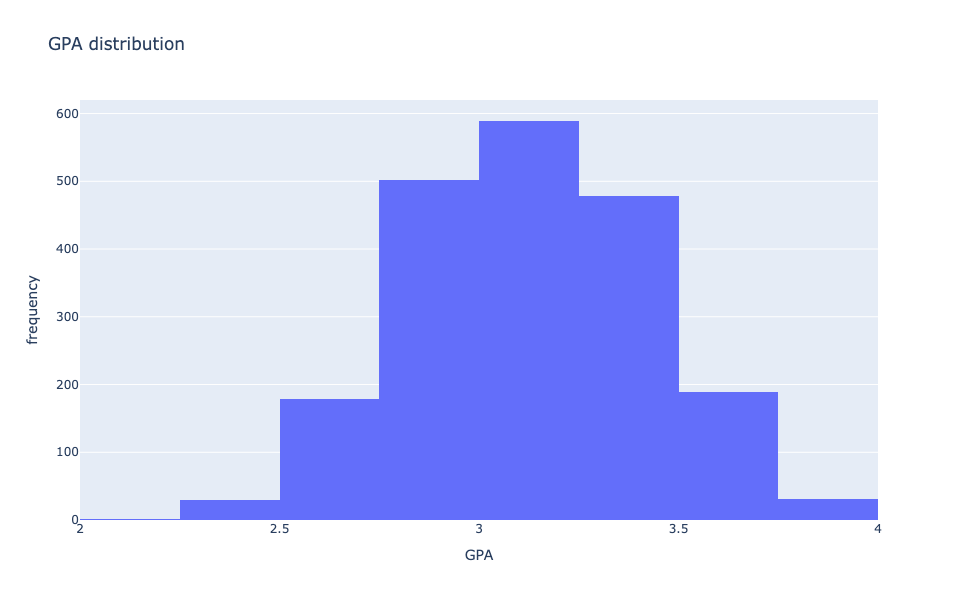

In [14]:
fig = px.histogram(
    df,
    x='gpa',
    title='GPA distribution',
    width=800,
    height=600
)
fig.update_traces(
    xbins={'start':2,'end':4,'size':0.25}
)
fig.update_layout(
    xaxis_title='GPA',
    yaxis_title='frequency'
)
fig.show()

The distribution for GPA is unimodal and fairly symmetric. The majority of the datapoints are within the 3.0 to 3.24 range with the center around 3.11 and the range is from 2.24 to 4.0 

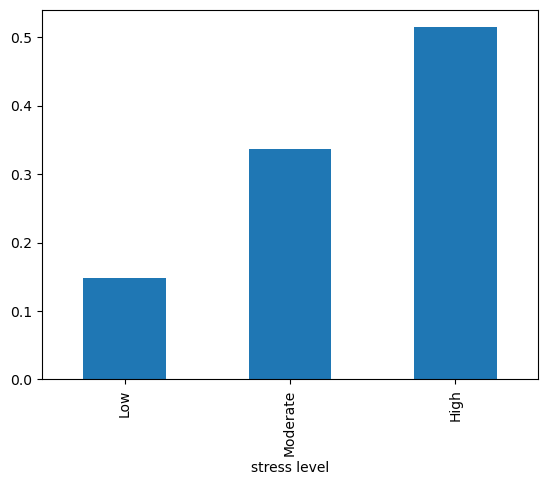

In [56]:
df['stress level'].value_counts(normalize=True, ascending=True).plot.bar();

About half of the data points are in the high stress level category, with the proportion of the data in the moderate stress level is about 0.35 and, and the proportion of the data in the low stress level category is about 0.15. 

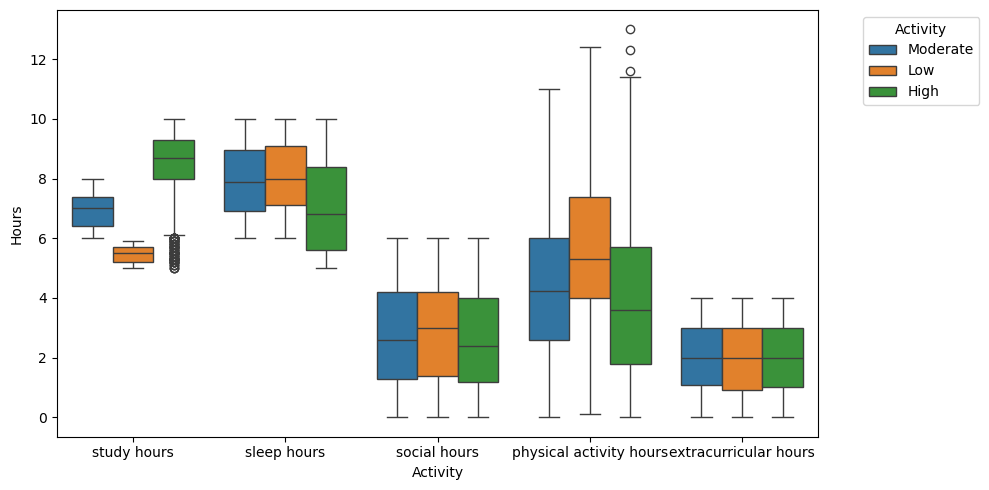

In [73]:
lifestyle = df.melt(
   id_vars='stress level',
   value_vars=['study hours', 'sleep hours', 'social hours', 'physical activity hours', 'extracurricular hours'],
   var_name='Activity',
   value_name='Hours'
)
plt.figure(figsize=(10, 5))
sns.boxplot(x='Activity', y='Hours', hue='stress level', data=lifestyle)
plt.legend(title='Activity', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

- **Study Hours:** Although there is a positive correlation between study hours and stress level, the same correlation applies to the variance and standard deviation of study hours and stress levels. Specifically, high stress levels can be explained by students not studying enough and therefore not fully understanding the content, or the material being difficult, so that no matter how long they are studying for, they are still not comprehending it.
- **Extracurricular Hours:** Extracurricular hours have little effect on stress level, and there is little difference in the variance and standard deviation among each category of stress level.
- **Sleep Hours:** High stress levels have the largest variance/standard deviation. This is due to the fact that sleep hours and GPA are negatively correlated, and a lower GPA equals more stress. On the contrary, not sleeping enough means that students will be more stressed because it interferes with their learning and ability to stay functional.
- **Social Hours:** Social hours do not have a significant impact on stress levels, but they are negatively correlated with each other. Humans are social beings, and having a support system and socializing has been proven to reduce stress.
- **Physical Activity Hours:** Physical activity hours and stress levels are negatively correlated. Exercising reduces stress hormones while boosting mood, energy, and ability to sleep.



### Now we can examine correlation between variables

In [57]:
num = df.copy()
num['stress level'] = num['stress level'].map({'Low':0, 'Moderate':1, 'High':2})

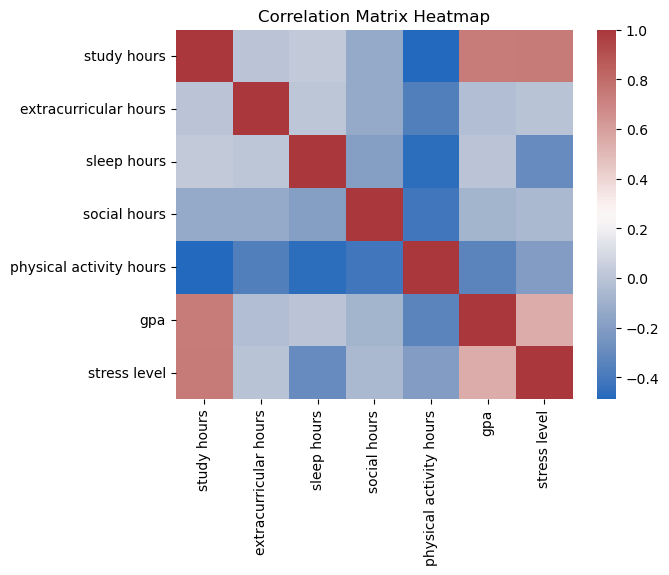

,study hours,extracurricular hours,sleep hours,social hours,physical activity hours,gpa,stress level
study hours,1.000000,-0.002629,0.026717,-0.137820,-0.488113,0.734468,0.738843
extracurricular hours,-0.002629,1.000000,0.008844,-0.139081,-0.369989,-0.032174,-0.006099
sleep hours,0.026717,0.008844,1.000000,-0.193556,-0.470302,-0.004278,-0.298917
social hours,-0.137820,-0.139081,-0.193556,1.000000,-0.417142,-0.085677,-0.054702
physical activity hours,-0.488113,-0.369989,-0.470302,-0.417142,1.000000,-0.341152,-0.205207
gpa,0.734468,-0.032174,-0.004278,-0.085677,-0.341152,1.000000,0.550395
stress level,0.738843,-0.006099,-0.298917,-0.054702,-0.205207,0.550395,1.000000


In [58]:
corr = num.drop(columns=['student id']).corr()
sns.heatmap(corr, cmap='vlag')
plt.title('Correlation Matrix Heatmap')
plt.show()
corr

This pairplot shows that most of the lifestyle factors in our dataset (namely, extracurricular hours, physical activity hours, sleep hours, and social hours) are generally negatively correlated with GPA and stress level. All of the lifestyle factors are negatively correlated with each other with makes sense because students have only a limited amount of hours to devote to various activities per week. Only study hours was positively correlated with GPA and a high stress level, with study hours having a fairly strong correlation of 0.734468 with GPA and 0.738843 with high stress level. Other noteworthy points of this plot include sleep hours being somewhat weakly negatively correlated with stress level with a coefficient of -0.298917 and physical activity hours also being  somewhat weakly negatively correlated with stress level with a coefficient of -0.205207. Social hours was quite weakly correlated with stress level with a coefficient of -0.054702. All three of these correlations were not necessarily strong support of our hypothesis that sleep hours, physical activity hours, and social hours would be more strongly indicative of lower stress levels. 

## Ethics

### A. Data Collection
 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

> We don't know how much/little information was given to subjects. There was at least some degree of consent as all subjects did submit a form, but we can't know whether they knew what the information would be used for.

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

> This is a specific subset of students (those who have gone through the Indian school system) due to the source of the data, which may not be perfectly representative of students in other countries. However, there's not much to be done about that without gathering our own data, so we just need to be mindful of this fact with the conclusions that we draw.

 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

> This has been done, all subjects are given anonymized ID numbers and names/actual identification information is not included.

 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?

> We do not control the data, all data has been and will continue to be publicly available.

 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?
 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?

> When writing our analysis, we'll be able to address blindspots by engaging with existing literature about the subject and therefore covering our blindspots through analysis and conclusions determined by subject matter experts. 

 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

> See **A.2**.

 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?

> Yes

 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?
 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

 > It hasn't been done yet, but it will be

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?

> None of these are directly discriminatory, and while you could make an argument that several of them are somewhat related to sensitive variables, it's all in somewhat indirect ways and none could be considered actual proxies.

 - [X] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?
 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?

> We tried to keep our metrics as "raw" as possible. That is to say, we are avoiding using proxies to minimize the effects of confounding variables and prevent optimization for those metrics from becoming less representative of what we are attempting to measure. GPA is a widely accepted standard for measuring academic performance and should be representative of it. Self-reported stress levels are the most unbiased way to measure stress we could think of.

 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?
 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?

> This is not a predictive model; rather we are examining whether a true predictive model *could* use these variables. It is not intended to be used as replacement for evaluating actual GPA or stress, for instance. The dataset it will be used on is constant, therefore none of these deployment considerations are particularly relevant.

 - [X] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?
 - [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?
 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?

## Team Expectations 

* *Communication: Our primary method of communication will be our messages groupchat which we'll use to discuss meeting times, questions, and other other concerns. Our expectation is that a message is responded to, at the very latest, 24 hours after it is sent.*
* *Responsibilities: Our responsibilities and roles will mostly be aligned with our strengths and what the project requires. Silas and Vivian will be programmers and Justin, Devon, and Medha will focus more on research and facilitating the project. However, we will cover other roles as needed through the project timeline and be flexibility to what we decide is needed.*
* *Conflict Resolution: If there is a conflict, we will communicate with each other respectfully and address everyone involved with grace. If someone is struggle to deliver work on time or in a thorough manner, we will discuss the issue as a group, provide support where needed, and stress the importance of staying on top of deadlines.*

## Project Timeline Proposal

| Meeting Date  | Meeting Time| Completed Before Meeting  | Discuss at Meeting |
|---|---|---|---|
| 2/2  |  6 PM | Brainstorming | Finish brainstorming topics and select one; start background research and work on project proposal | 
| 2/3  |  6 PM |  Edit and finalize proposal, submit by 2/4 latest | Continue background research and search for datasets |
| 2/11  | 4 PM  | - | Catch up new group member and prepare for next checkpoint |
| 2/17  | 5 PM  | Read feedback for previous checkpoint and instructions for next | Fix proposal, make writeup for checkpoint 1 |
| 3/3  | 3 PM  | EDA graphs | Write up analysis and organize checkpoint for submission |
| 3/5  | 4 PM  | EDA checkpoint | Work on and discuss analysis |
| 3/12  | 4 PM  | EDA checkpoint| Complete analysis; start finalizing and editing entire project|
| 3/20  | Before 11:59 PM  | Project | Turn in Final Project & Group Project Surveys |